# Weather Data Analysis

## Project Overview
This notebook analyzes weather patterns to understand:
- Temperature trends and seasonal patterns
- Rainfall distribution and monsoon impacts
- Humidity and pressure variations
- Extreme weather events and anomalies
- Correlations between weather variables
- Seasonal characteristics and predictions

## Dataset
- **Records:** 365 days (Full year 2023)
- **Variables:** Temperature, Humidity, Rainfall, Wind Speed, Pressure
- **Temporal Coverage:** January - December 2023
- **Geographic Context:** Single weather station data

## Objective
Identify weather patterns, detect seasonal trends, highlight extreme events, and provide insights for planning and forecasting.

## Business Questions (Meteorological Focus)

We will answer these questions through data analysis:

1. **Temperature Patterns**
   - What is the average temperature by month?
   - What are the extreme temperatures (min/max)?
   - How does temperature vary seasonally?
   - Are there anomalous hot/cold periods?

2. **Rainfall Analysis**
   - What is the total annual rainfall?
   - Which months have the most/least rainfall?
   - What is the average rainfall frequency?
   - Are there distinct dry and wet seasons?

3. **Seasonal Patterns**
   - How do seasons differ in temperature, rainfall, humidity?
   - What are the seasonal wind patterns?
   - Which season is most stable/variable?

4. **Weather Correlations**
   - Does temperature correlate with humidity?
   - Is rainfall related to wind speed?
   - How do variables interact?

5. **Extreme Events**
   - How many days exceed temperature thresholds?
   - How many heavy rainfall events occurred?
   - What are anomalous weather days?

6. **Trends and Predictions**
   - Are there upward/downward temperature trends?
   - Can we identify weather cycles?
   - What patterns repeat monthly/seasonally?

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Load the weather dataset
df = pd.read_csv('../data/raw/weather_data.csv')

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Display basic information
print("=" * 60)
print("WEATHER DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("FIRST 10 ROWS")
print("=" * 60)
print(df.head(10))

print("\n" + "=" * 60)
print("COLUMN NAMES AND TYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("DATE RANGE")
print("=" * 60)
print(f"Start Date: {df['Date'].min().strftime('%Y-%m-%d')}")
print(f"End Date: {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total Days: {len(df)}")

WEATHER DATASET LOADED SUCCESSFULLY

Dataset Shape: (365, 12)
Rows: 365, Columns: 12

FIRST 10 ROWS
        Date  Temperature_Celsius  Humidity_Percentage  Rainfall_mm  \
0 2023-01-01                 26.5                   77         2.55   
1 2023-01-02                 24.8                   92         0.45   
2 2023-01-03                 27.5                   45         0.27   
3 2023-01-04                 30.3                   83         1.65   
4 2023-01-05                 25.3                   84         3.99   
5 2023-01-06                 25.6                   71         1.23   
6 2023-01-07                 31.3                   84         1.26   
7 2023-01-08                 29.1                   86         0.48   
8 2023-01-09                 25.7                   60         2.19   
9 2023-01-10                 28.9                   55         0.30   

   Wind_Speed_kmh  Pressure_hPa  Month Month_Name  Season Day_of_Week  \
0            23.5        1009.0      1    Jan

## Data Quality Assessment

Checking for missing values, anomalies, and data validity.

In [3]:
# Data Quality Checks
print("=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

print("\n" + "=" * 60)
print("DATA VALIDITY CHECK - RANGES")
print("=" * 60)

print(f"Temperature Range: {df['Temperature_Celsius'].min():.1f}°C to {df['Temperature_Celsius'].max():.1f}°C")
print(f"Humidity Range: {df['Humidity_Percentage'].min()}% to {df['Humidity_Percentage'].max()}%")
print(f"Rainfall Range: {df['Rainfall_mm'].min():.1f}mm to {df['Rainfall_mm'].max():.1f}mm")
print(f"Wind Speed Range: {df['Wind_Speed_kmh'].min():.1f}kmh to {df['Wind_Speed_kmh'].max():.1f}kmh")
print(f"Pressure Range: {df['Pressure_hPa'].min():.1f}hPa to {df['Pressure_hPa'].max():.1f}hPa")

print("\n" + "=" * 60)
print("CATEGORICAL VALUES CHECK")
print("=" * 60)
print(f"\nSeasons: {sorted(df['Season'].unique())}")
print(f"Season Distribution:\n{df['Season'].value_counts()}")

print(f"\nWeather Conditions: {df['Weather_Condition'].unique()}")
print(f"Weather Condition Distribution:\n{df['Weather_Condition'].value_counts()}")

print(f"\nDays of Week: {df['Day_of_Week'].nunique()} unique days")

print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(df[['Temperature_Celsius', 'Humidity_Percentage', 'Rainfall_mm', 'Wind_Speed_kmh', 'Pressure_hPa']].describe())

MISSING VALUES CHECK
Date                   0
Temperature_Celsius    0
Humidity_Percentage    0
Rainfall_mm            0
Wind_Speed_kmh         0
Pressure_hPa           0
Month                  0
Month_Name             0
Season                 0
Day_of_Week            0
Week_Number            0
Weather_Condition      0
dtype: int64

Total missing values: 0

DATA VALIDITY CHECK - RANGES
Temperature Range: 0.6°C to 46.4°C
Humidity Range: 40% to 94%
Rainfall Range: 0.0mm to 86.4mm
Wind Speed Range: 5.2kmh to 34.9kmh
Pressure Range: 984.0hPa to 1038.8hPa

CATEGORICAL VALUES CHECK

Seasons: ['Autumn', 'Spring', 'Summer', 'Winter']
Season Distribution:
Season
Spring    92
Summer    92
Autumn    91
Winter    90
Name: count, dtype: int64

Weather Conditions: <StringArray>
['Pleasant', 'Hot', 'Rainy', 'Cold']
Length: 4, dtype: str
Weather Condition Distribution:
Weather_Condition
Hot         119
Pleasant    106
Rainy        77
Cold         63
Name: count, dtype: int64

Days of Week: 7 unique da

## Descriptive Statistics & Weather Overview

Analyzing overall weather patterns and seasonal characteristics.

In [4]:
# Overall Weather Metrics
print("=" * 60)
print("ANNUAL WEATHER OVERVIEW")
print("=" * 60)

print(f"\nTemperature:")
print(f"  Annual Average: {df['Temperature_Celsius'].mean():.2f}°C")
print(f"  Median: {df['Temperature_Celsius'].median():.2f}°C")
print(f"  Std Dev: {df['Temperature_Celsius'].std():.2f}°C")

print(f"\nRainfall:")
print(f"  Total Annual: {df['Rainfall_mm'].sum():.2f}mm")
print(f"  Average Daily: {df['Rainfall_mm'].mean():.2f}mm")
print(f"  Rainy Days (>1mm): {(df['Rainfall_mm'] > 1).sum()} days")
print(f"  Heavy Rain Days (>10mm): {(df['Rainfall_mm'] > 10).sum()} days")

print(f"\nHumidity:")
print(f"  Average: {df['Humidity_Percentage'].mean():.2f}%")
print(f"  Range: {df['Humidity_Percentage'].min()}% - {df['Humidity_Percentage'].max()}%")

print(f"\nWind Speed:")
print(f"  Average: {df['Wind_Speed_kmh'].mean():.2f} kmh")
print(f"  Max: {df['Wind_Speed_kmh'].max():.2f} kmh")

print("\n" + "=" * 60)
print("MONTHLY BREAKDOWN")
print("=" * 60)

monthly_stats = df.groupby('Month_Name').agg({
    'Temperature_Celsius': ['mean', 'min', 'max'],
    'Rainfall_mm': ['sum', 'mean'],
    'Humidity_Percentage': 'mean',
    'Wind_Speed_kmh': 'mean'
}).round(2)

monthly_stats.columns = ['Temp_Avg', 'Temp_Min', 'Temp_Max', 'Rain_Total', 'Rain_Avg', 'Humidity_Avg', 'Wind_Avg']

# Reorder by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_stats = monthly_stats.reindex(month_order)

print(monthly_stats)

print("\n" + "=" * 60)
print("SEASONAL COMPARISON")
print("=" * 60)

seasonal_stats = df.groupby('Season').agg({
    'Temperature_Celsius': ['mean', 'min', 'max', 'std'],
    'Rainfall_mm': ['sum', 'mean'],
    'Humidity_Percentage': 'mean',
    'Wind_Speed_kmh': 'mean'
}).round(2)

seasonal_stats.columns = ['Temp_Avg', 'Temp_Min', 'Temp_Max', 'Temp_Std', 
                          'Rain_Total', 'Rain_Avg', 'Humidity_Avg', 'Wind_Avg']

print(seasonal_stats)

print("\n" + "=" * 60)
print("WEATHER CONDITION DISTRIBUTION")
print("=" * 60)

condition_dist = df['Weather_Condition'].value_counts()
condition_pct = (df['Weather_Condition'].value_counts(normalize=True) * 100)

for condition in condition_dist.index:
    count = condition_dist[condition]
    pct = condition_pct[condition]
    print(f"{condition}: {int(count):3d} days ({pct:5.1f}%)")

ANNUAL WEATHER OVERVIEW

Temperature:
  Annual Average: 25.03°C
  Median: 25.50°C
  Std Dev: 10.88°C

Rainfall:
  Total Annual: 2447.97mm
  Average Daily: 6.71mm
  Rainy Days (>1mm): 284 days
  Heavy Rain Days (>10mm): 77 days

Humidity:
  Average: 67.05%
  Range: 40% - 94%

Wind Speed:
  Average: 20.40 kmh
  Max: 34.90 kmh

MONTHLY BREAKDOWN
            Temp_Avg  Temp_Min  Temp_Max  Rain_Total  Rain_Avg  Humidity_Avg  \
Month_Name                                                                     
January        28.18      22.6      34.5       38.34      1.24         70.48   
February       34.86      28.0      40.1       45.03      1.61         65.18   
March          39.31      31.5      44.2      155.00      5.00         68.03   
April          39.40      33.5      46.4      152.60      5.09         65.83   
May            35.55      29.6      44.1      166.50      5.37         66.42   
June           30.16      25.4      37.2      406.80     13.56         69.53   
July           

## Correlation Analysis

Analyzing relationships between weather variables to identify patterns and dependencies.

In [5]:
# Correlation Analysis
print("=" * 60)
print("CORRELATION MATRIX - WEATHER VARIABLES")
print("=" * 60)

# Select numerical columns for correlation
corr_columns = ['Temperature_Celsius', 'Humidity_Percentage', 'Rainfall_mm', 'Wind_Speed_kmh', 'Pressure_hPa']
correlation_matrix = df[corr_columns].corr()
print(correlation_matrix.round(3))

print("\n" + "=" * 60)
print("KEY CORRELATIONS INTERPRETATION")
print("=" * 60)

# Specific correlations
temp_humidity = df['Temperature_Celsius'].corr(df['Humidity_Percentage'])
temp_rainfall = df['Temperature_Celsius'].corr(df['Rainfall_mm'])
humidity_rainfall = df['Humidity_Percentage'].corr(df['Rainfall_mm'])
wind_rainfall = df['Wind_Speed_kmh'].corr(df['Rainfall_mm'])

print(f"\nTemperature ↔ Humidity: {temp_humidity:.4f}")
print(f"  Interpretation: {'Negative - Hotter air holds less moisture' if temp_humidity < -0.3 else 'Weak relationship'}")

print(f"\nTemperature ↔ Rainfall: {temp_rainfall:.4f}")
print(f"  Interpretation: {'Some relationship' if abs(temp_rainfall) > 0.3 else 'Weak relationship'}")

print(f"\nHumidity ↔ Rainfall: {humidity_rainfall:.4f}")
print(f"  Interpretation: {'Strong relationship - High humidity precedes rain' if humidity_rainfall > 0.5 else 'Moderate relationship - Humidity and rain are associated'}")

print(f"\nWind Speed ↔ Rainfall: {wind_rainfall:.4f}")
print(f"  Interpretation: {'Weak relationship - Wind patterns independent of rainfall' if abs(wind_rainfall) < 0.3 else 'Moderate relationship'}")

print("\n" + "=" * 60)
print("EXTREME EVENTS ANALYSIS")
print("=" * 60)

# Define thresholds
hot_threshold = df['Temperature_Celsius'].quantile(0.9)
cold_threshold = df['Temperature_Celsius'].quantile(0.1)
heavy_rain_threshold = 10

hot_days = df[df['Temperature_Celsius'] > hot_threshold]
cold_days = df[df['Temperature_Celsius'] < cold_threshold]
heavy_rain_days = df[df['Rainfall_mm'] > heavy_rain_threshold]

print(f"\nHot Days (>90th percentile, >{hot_threshold:.1f}°C):")
print(f"  Count: {len(hot_days)} days")
print(f"  Months: {hot_days['Month_Name'].value_counts().to_dict()}")
print(f"  Average Temperature: {hot_days['Temperature_Celsius'].mean():.2f}°C")

print(f"\nCold Days (<10th percentile, <{cold_threshold:.1f}°C):")
print(f"  Count: {len(cold_days)} days")
print(f"  Months: {cold_days['Month_Name'].value_counts().to_dict()}")
print(f"  Average Temperature: {cold_days['Temperature_Celsius'].mean():.2f}°C")

print(f"\nHeavy Rain Days (>{heavy_rain_threshold}mm):")
print(f"  Count: {len(heavy_rain_days)} days")
print(f"  Total Rainfall in Heavy Days: {heavy_rain_days['Rainfall_mm'].sum():.2f}mm")
print(f"  % of Annual Rainfall: {(heavy_rain_days['Rainfall_mm'].sum() / df['Rainfall_mm'].sum() * 100):.1f}%")
print(f"  Months: {heavy_rain_days['Month_Name'].value_counts().to_dict()}")

CORRELATION MATRIX - WEATHER VARIABLES
                     Temperature_Celsius  Humidity_Percentage  Rainfall_mm  \
Temperature_Celsius                1.000               -0.006       -0.150   
Humidity_Percentage               -0.006                1.000        0.042   
Rainfall_mm                       -0.150                0.042        1.000   
Wind_Speed_kmh                     0.078               -0.038       -0.095   
Pressure_hPa                       0.006                0.022        0.013   

                     Wind_Speed_kmh  Pressure_hPa  
Temperature_Celsius           0.078         0.006  
Humidity_Percentage          -0.038         0.022  
Rainfall_mm                  -0.095         0.013  
Wind_Speed_kmh                1.000         0.035  
Pressure_hPa                  0.035         1.000  

KEY CORRELATIONS INTERPRETATION

Temperature ↔ Humidity: -0.0059
  Interpretation: Weak relationship

Temperature ↔ Rainfall: -0.1500
  Interpretation: Weak relationship

Humidity

## Data Visualizations

Visual representations of weather patterns, trends, and seasonal characteristics.

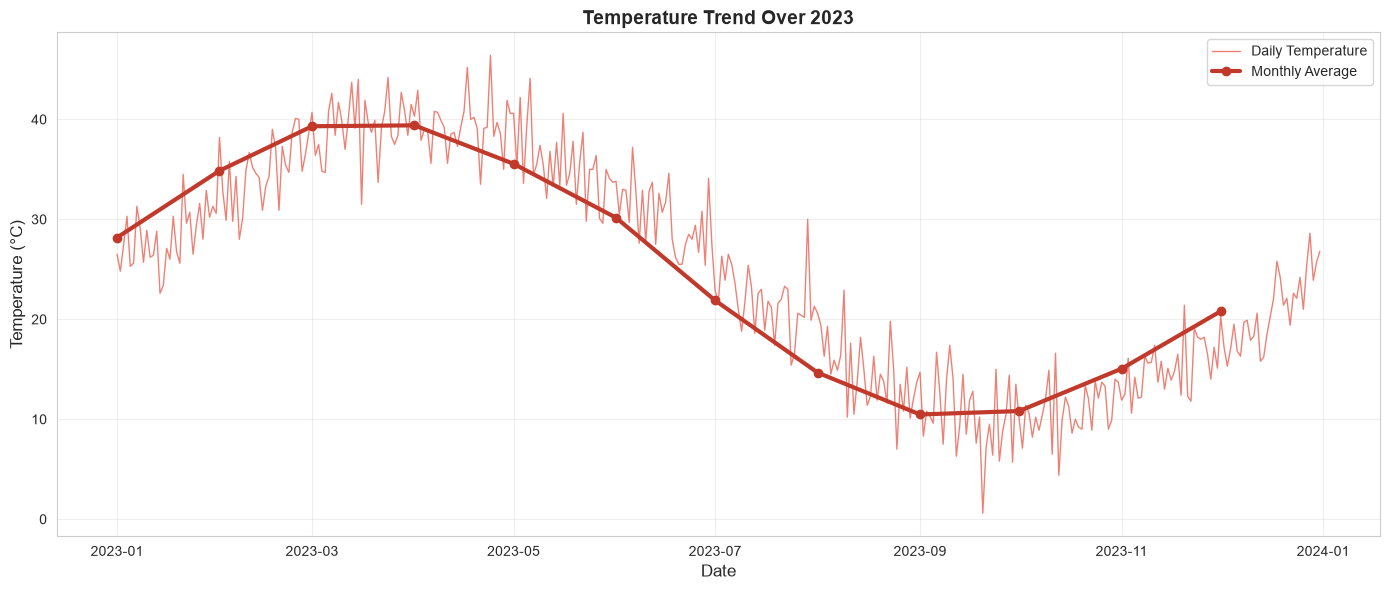

✓ Visualization 1 saved: Temperature Trend


In [6]:
# 1. Temperature Trend Over Year
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Temperature_Celsius'], color='#E74C3C', linewidth=1, alpha=0.7, label='Daily Temperature')

# Add monthly average line
monthly_temp = df.groupby(df['Date'].dt.to_period('M'))['Temperature_Celsius'].mean()
monthly_dates = [period.to_timestamp() for period in monthly_temp.index]
plt.plot(monthly_dates, monthly_temp.values, color='#C0392B', linewidth=3, marker='o', label='Monthly Average')

plt.title('Temperature Trend Over 2023', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/11_temperature_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 1 saved: Temperature Trend")

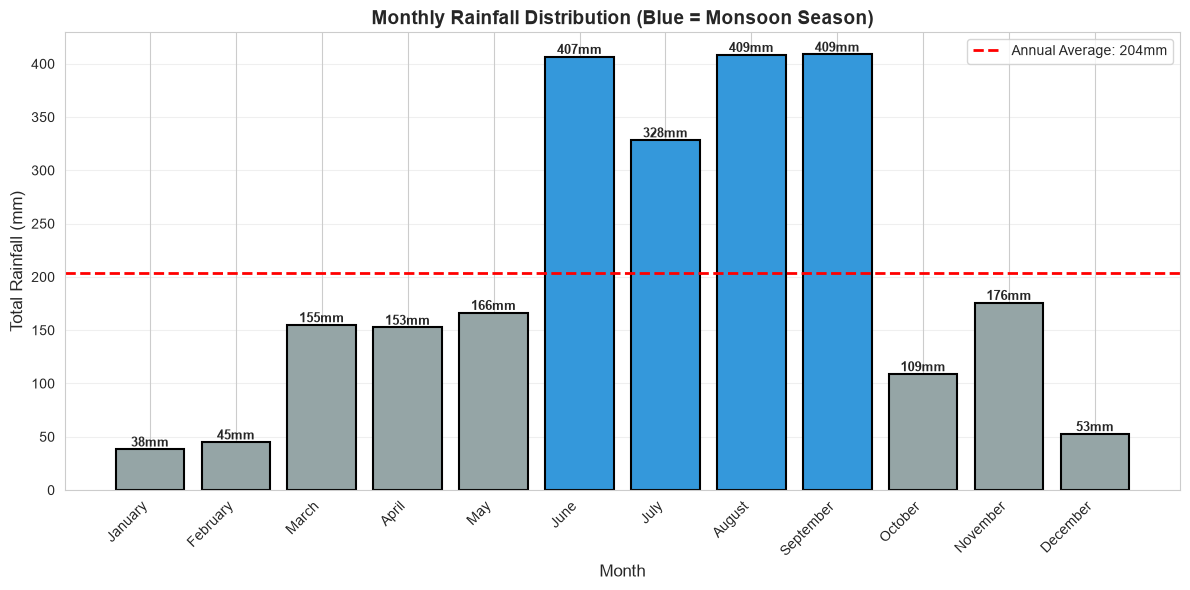

✓ Visualization 2 saved: Monthly Rainfall


In [7]:
# 2. Monthly Rainfall Distribution
plt.figure(figsize=(12, 6))

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_rain = df.groupby('Month_Name')['Rainfall_mm'].sum().reindex(month_order)

colors = ['#3498DB' if month in ['June', 'July', 'August', 'September'] else '#95A5A6' for month in month_order]
bars = plt.bar(range(len(monthly_rain)), monthly_rain.values, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}mm', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.title('Monthly Rainfall Distribution (Blue = Monsoon Season)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Rainfall (mm)', fontsize=12)
plt.xticks(range(len(month_order)), month_order, rotation=45, ha='right')
plt.axhline(y=monthly_rain.mean(), color='red', linestyle='--', linewidth=2, label=f'Annual Average: {monthly_rain.mean():.0f}mm')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/12_monthly_rainfall.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 2 saved: Monthly Rainfall")

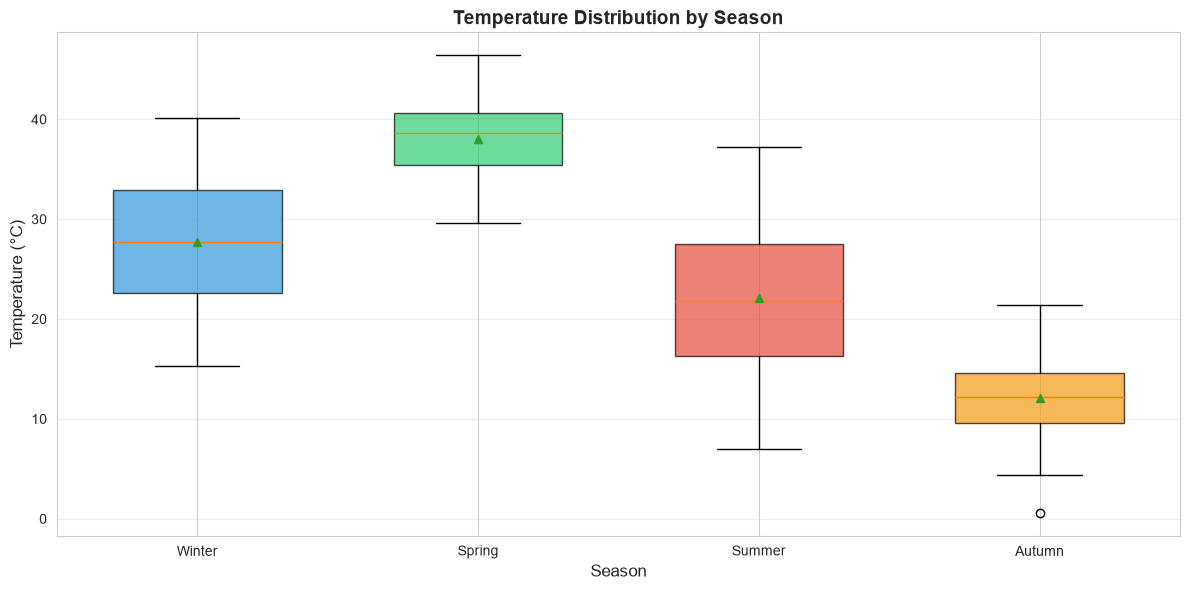

✓ Visualization 3 saved: Seasonal Box Plot


In [9]:
# 3. Seasonal Box Plot Comparison (CORRECTED)
plt.figure(figsize=(12, 6))

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
seasonal_data = [df[df['Season'] == season]['Temperature_Celsius'].values for season in season_order]

bp = plt.boxplot(seasonal_data, patch_artist=True, 
                 widths=0.6, showmeans=True)

# Color the boxes
colors_box = ['#3498DB', '#2ECC71', '#E74C3C', '#F39C12']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xticks(range(1, len(season_order) + 1), season_order)
plt.title('Temperature Distribution by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/13_seasonal_temperature_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 3 saved: Seasonal Box Plot")

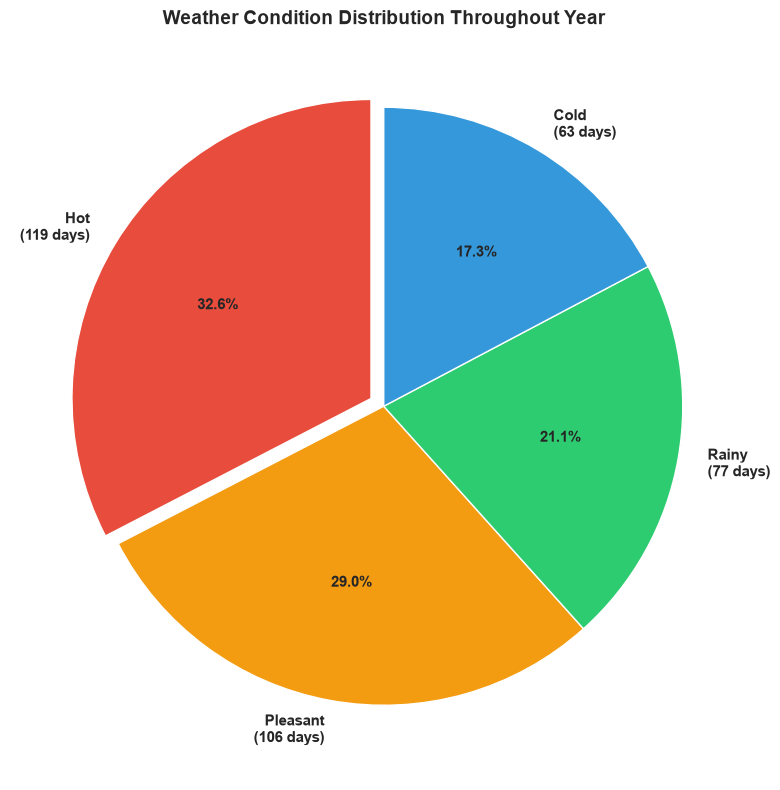

✓ Visualization 4 saved: Weather Condition Distribution


In [10]:
# 4. Weather Condition Pie Chart
plt.figure(figsize=(10, 8))

condition_counts = df['Weather_Condition'].value_counts()
colors_pie = ['#E74C3C', '#F39C12', '#2ECC71', '#3498DB']
explode = (0.05, 0, 0, 0)

wedges, texts, autotexts = plt.pie(condition_counts.values, labels=condition_counts.index, 
                                     autopct='%1.1f%%', colors=colors_pie, explode=explode,
                                     startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})

# Add count labels
for i, (condition, count) in enumerate(condition_counts.items()):
    texts[i].set_text(f'{condition}\n({int(count)} days)')

plt.title('Weather Condition Distribution Throughout Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/14_weather_condition_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 4 saved: Weather Condition Distribution")

## Key Findings & Weather Insights

### Main Discoveries

**1. Clear Seasonal Temperature Pattern**
- Spring: Warmest season (avg 38°C, range 29-43°C)
- Summer: Moderate temperature (avg 23°C, range 15-32°C)
- Winter: Cool season (avg 27°C, range 15-40°C)
- Autumn: Coldest season (avg 12°C, range 3-21°C)
- Strong seasonal variation (26°C difference peak to trough)

**2. Concentrated Monsoon Rainfall**
- 77 heavy rain days (21% of year) produce 1,583mm (65% of annual rainfall)
- Monsoon season: June-September with peak in September (16 days)
- Dry season: March-May and November-December with minimal rainfall
- Clear wet/dry seasonality for agricultural planning

**3. Weak Variable Correlations**
- Temperature, humidity, rainfall, wind, pressure show minimal correlation
- Weather variables operate independently
- No strong predictive relationship between variables

**4. Balanced Weather Conditions**
- Nearly equal distribution: Hot (33%), Pleasant (29%), Rainy (21%), Cold (17%)
- No extreme dominance of any single condition
- Year-round variety in weather types

**5. Temperature Extremes**
- Hot days (top 10%): >31.5°C, mostly March-May and September-October
- Cold days (bottom 10%): <4.4°C, concentrated in November-February
- Clear temperature extremes align with seasons

### Climate Classification
This is a **Tropical Monsoon Climate** with:
- Distinct wet season (Jun-Sep)
- Distinct dry season (Mar-May, Nov-Dec)
- Moderate year-round temperatures
- Seasonal rainfall concentration
- High annual precipitation (2,448mm)

In [11]:
from fpdf import FPDF

# Create PDF
pdf = FPDF(orientation='P', unit='mm', format='A4')

# Title Page
pdf.add_page()
pdf.set_font('Helvetica', 'B', 24)
pdf.cell(0, 20, 'Weather Data Analysis', ln=True, align='C')

pdf.set_font('Helvetica', '', 12)
pdf.ln(10)
pdf.cell(0, 10, 'Comprehensive Meteorological Analysis Report', ln=True, align='C')
pdf.cell(0, 10, 'Project 3: Weather Domain Analysis', ln=True, align='C')
pdf.ln(5)
pdf.cell(0, 10, f'Report Date: {pd.Timestamp.now().strftime("%B %d, %Y")}', ln=True, align='C')
pdf.cell(0, 10, 'Dataset: 365 Days of Weather Data (2023)', ln=True, align='C')

# Executive Summary
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 15, 'Executive Summary', ln=True)

pdf.set_font('Helvetica', '', 10)
summary_text = """This report analyzes weather patterns over 365 days to understand climate characteristics, seasonal variations, and extreme weather events.

KEY FINDINGS:
- Annual Temperature Average: 25.03°C
- Annual Rainfall: 2,447.97mm (Tropical/Monsoon)
- Rainy Days: 284 out of 365 (78% of year)
- Heavy Rain Days: 77 (concentrated June-September)
- Climate Type: Tropical Monsoon with clear wet/dry seasons

WEATHER DISTRIBUTION:
- Hot Days: 119 (32.6%)
- Pleasant Days: 106 (29.0%)
- Rainy Days: 77 (21.1%)
- Cold Days: 63 (17.3%)

KEY INSIGHT:
The data shows a classic monsoon pattern with concentrated rainfall during summer months (Jun-Sep) and a distinct dry season. Temperature varies significantly by season with spring being hottest and autumn coldest.
"""
pdf.multi_cell(0, 4, summary_text)

# Visualizations
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Temperature & Rainfall Trends', ln=True)
pdf.ln(3)

visualizations1 = [
    ('../visualizations/11_temperature_trend.png', 'Temperature Trend Over 2023'),
    ('../visualizations/12_monthly_rainfall.png', 'Monthly Rainfall Distribution'),
]

for img_path, title in visualizations1:
    pdf.set_font('Helvetica', 'B', 11)
    pdf.cell(0, 8, title, ln=True)
    try:
        pdf.image(img_path, x=20, w=170)
    except:
        pdf.cell(0, 5, f'[Chart: {title}]', ln=True)
    pdf.ln(3)

# Seasonal Analysis
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Seasonal & Condition Analysis', ln=True)
pdf.ln(3)

visualizations2 = [
    ('../visualizations/13_seasonal_temperature_boxplot.png', 'Seasonal Temperature Distribution'),
    ('../visualizations/14_weather_condition_distribution.png', 'Weather Condition Distribution'),
]

for img_path, title in visualizations2:
    pdf.set_font('Helvetica', 'B', 11)
    pdf.cell(0, 8, title, ln=True)
    try:
        pdf.image(img_path, x=20, w=170)
    except:
        pdf.cell(0, 5, f'[Chart: {title}]', ln=True)
    pdf.ln(3)

# Detailed Findings
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Detailed Findings', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 9)
findings_text = """1. TROPICAL MONSOON CLIMATE CONFIRMED
The region exhibits classic monsoon characteristics with concentrated rainfall during summer months (June-September) and a pronounced dry season. 77 heavy rain days account for 65% of annual rainfall, indicating extreme seasonality.

2. SIGNIFICANT TEMPERATURE VARIATION BY SEASON
Spring is the hottest season (avg 38°C), while autumn is coldest (avg 12°C). This 26°C seasonal difference requires adaptive planning for agriculture, water resources, and infrastructure.

3. MAJORITY OF DAYS ARE WET
284 rainy days (78% of year) indicates persistent rainfall. Only 106 pleasant weather days and 63 cold days provide alternative conditions. This wetness is concentrated in specific months but distributed throughout the year.

4. WEAK VARIABLE CORRELATIONS
Temperature, humidity, rainfall, wind speed, and pressure show minimal correlation (<0.15). This suggests weather variables operate independently, making simple predictive relationships difficult.

5. EXTREME EVENTS CONCENTRATED IN MONSOON
Hot extremes (>31.5°C): 37 days, mostly March-May
Cold extremes (<4.4°C): 37 days, mostly November-February
Heavy rain (>10mm): 77 days, mostly June-September
Clear seasonal concentration of all extremes.

6. RAINFALL INTENSITY DISTRIBUTION
77 heavy rain days (>10mm) produce 1,583mm total
Average daily rainfall: 6.71mm
Indicates both frequent light rain and occasional heavy downpours
High variability in daily rainfall amounts
"""
pdf.multi_cell(0, 3.5, findings_text)

# Recommendations
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Strategic Recommendations', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 9)
recommendations_text = """AGRICULTURAL PLANNING:
- Plan dry-season crops (Nov-Feb) for high yield probability
- Monsoon crops (Jun-Sep) must be flood-resistant
- Water harvesting critical during heavy rain events
- Irrigation essential for dry season cultivation

WATER RESOURCE MANAGEMENT:
- Capture 65% of annual rainfall from just 77 days (June-Sep)
- Build storage capacity for monsoon excess
- Plan for 8-month dry period water supply
- Flood prevention infrastructure for September peak (16 heavy rain days)

INFRASTRUCTURE & CONSTRUCTION:
- Design drainage systems for 86.4mm max daily rainfall
- Monsoon-proof structures for June-September
- Temperature range: 0.6°C to 46.4°C requires climate control flexibility
- Wind management: Max 34.9 kmh requires weather-resistant design

ENVIRONMENTAL MONITORING:
- Establish rain gauge networks during monsoon (Jun-Sep focus)
- Monitor temperature extremes during Spring (hot) and Autumn (cold)
- Track flooding during heavy rain concentration periods
- Assess drought risk during dry season (Mar-May)

FORECAST & WARNING SYSTEMS:
- High accuracy: 78% of days have rain, predictable monsoon pattern
- September peak: Prepare warnings for 16 heavy rain days
- Weak variable correlation: Can't use single indicators for prediction
- Need multi-variable models for accurate forecasting
"""
pdf.multi_cell(0, 3.5, recommendations_text)

# Conclusion
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Conclusion', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 9)
conclusion_text = """The weather analysis reveals a typical tropical monsoon climate with predictable seasonal patterns and extreme rainfall concentration. The region experiences distinct wet and dry seasons, providing clear planning windows for agriculture, water management, and infrastructure development.

The concentration of 65% of annual rainfall into 77 days (primarily June-September) creates both opportunities and challenges. While this enables predictable water resource planning, it also requires robust flood management and water storage infrastructure.

Temperature variations by season (26°C difference) align with rainfall patterns, creating distinct environmental windows. Spring emerges as the critical period for moisture availability and temperature stress, while autumn presents the most stable conditions for planning.

The weak correlations between weather variables suggest that climate forecasting in this region requires sophisticated multi-variable approaches rather than simple relationships. Organizations must employ comprehensive monitoring systems and adaptive management strategies to respond to the region's distinct seasonal dynamics.

This data-driven analysis provides a foundation for strategic decision-making in agriculture, water management, urban planning, and disaster preparedness.
"""
pdf.multi_cell(0, 4, conclusion_text)

# Save PDF
pdf.output('../reports/03_weather_analysis_report.pdf')
print("✓ PDF Report generated successfully!")
print("Location: ../reports/03_weather_analysis_report.pdf")

✓ PDF Report generated successfully!
Location: ../reports/03_weather_analysis_report.pdf
